# 🍽️ Tips Dataset — Exploratory Data Analysis

**Author:** Devesh  
**Date:** Day 14 of the AI / ML RoadMap  
**Dataset:** Seaborn built-in *Tips* dataset (244 restaurant bills with tip amounts, party info, and context)

---

### Objective
Understand what drives tipping behaviour by cleaning, engineering features, running group-level analyses, and building publication-ready visualisations.

## 1 · Load & First Look

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Load the dataset
df = sns.load_dataset("tips")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)

Shape: 244 rows × 7 columns



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [3]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**What the dataset contains:**  
Each row is a single restaurant bill. We have the **total bill** and **tip** in dollars, the **sex** of the bill-payer, whether they are a **smoker**, the **day** of the week, whether it was **Lunch** or **Dinner**, and the **size** (number of people in the party).  
With 244 observations and 7 columns it's a compact but rich dataset for studying tipping patterns.

## 2 · Data Cleaning

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()}")

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Total missing: 0


In [5]:
# Check for duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"  → Dropped {dup_count} duplicates. New shape: {df.shape}")

Duplicate rows: 1
  → Dropped 1 duplicates. New shape: (243, 7)


In [6]:
# Data types — categorical columns should be 'category'
print("Current dtypes:")
print(df.dtypes)
print()

# Convert object / category columns explicitly
for col in ["sex", "smoker", "day", "time"]:
    df[col] = df[col].astype("category")

print("After conversion:")
print(df.dtypes)

Current dtypes:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

After conversion:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


**Cleaning decisions:**

| Check | Finding | Action |
|-------|---------|--------|
| Missing values | **Zero** missing values across all 7 columns | No imputation needed |
| Duplicates | Any exact-duplicate rows | Dropped (if found) — a duplicate bill entry is almost certainly a data-entry error |
| Data types | `sex`, `smoker`, `day`, `time` stored as generic objects | Converted to **category** dtype for memory efficiency and correct semantics |
| Useless columns | All 7 columns carry useful information | **No columns dropped** — even `size` (party size) turns out to be analytically valuable |

The dataset is already quite clean — a benefit of using a curated Seaborn built-in.

## 3 · Feature Engineering

In [7]:
# 1. Tip percentage — the most natural normalised measure of generosity
df["tip_pct"] = (df["tip"] / df["total_bill"] * 100).round(2)

# 2. Per-person bill — controls for party size
df["per_person_bill"] = (df["total_bill"] / df["size"]).round(2)

# 3. Bill category — useful for binned analysis
df["bill_category"] = pd.cut(
    df["total_bill"],
    bins=[0, 15, 30, 55],
    labels=["Low (<$15)", "Medium ($15–30)", "High (>$30)"]
)

# 4. Is large party — parties of 4+ behave differently
df["is_large_party"] = (df["size"] >= 4).astype(int)

print("New columns added: tip_pct, per_person_bill, bill_category, is_large_party\n")
df.head(10)

New columns added: tip_pct, per_person_bill, bill_category, is_large_party



,total_bill,tip,sex,smoker,day,time,size,tip_pct,per_person_bill,bill_category,is_large_party
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94,8.49,Medium ($15–30),0
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05,3.45,Low (<$15),0
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66,7.00,Medium ($15–30),0
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98,11.84,Medium ($15–30),0
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68,6.15,Medium ($15–30),1
5,25.29,4.71,Male,No,Sun,Dinner,4,18.62,6.32,Medium ($15–30),1
6,8.77,2.00,Male,No,Sun,Dinner,2,22.81,4.38,Low (<$15),0
7,26.88,3.12,Male,No,Sun,Dinner,4,11.61,6.72,Medium ($15–30),1
8,15.04,1.96,Male,No,Sun,Dinner,2,13.03,7.52,Medium ($15–30),0
9,14.78,3.23,Male,No,Sun,Dinner,2,21.85,7.39,Low (<$15),0


**Engineered features:**

- **`tip_pct`** — Tip as a percentage of the total bill. This normalises for bill size so we can fairly compare a $2 tip on a $10 bill vs. a $5 tip on a $50 bill.
- **`per_person_bill`** — Total bill divided by party size. Lets us ask "how much does each person spend on average?"
- **`bill_category`** — Bins the total bill into Low / Medium / High brackets for cleaner grouped analysis.
- **`is_large_party`** — Binary flag for parties of 4 or more, since large groups may tip differently.

## 4 · Group-Level Analysis

### Q1 — Do smokers tip more or less generously than non-smokers?

In [8]:
smoker_stats = df.groupby("smoker", observed=True).agg(
    avg_tip_pct=("tip_pct", "mean"),
    median_tip_pct=("tip_pct", "median"),
    avg_bill=("total_bill", "mean"),
    count=("tip", "count")
).round(2)

print(smoker_stats)
print()
print("→ Smokers actually tip a HIGHER percentage on average, though the difference is modest.")

        avg_tip_pct  median_tip_pct  avg_bill  count
smoker                                              
Yes           16.33           15.40     20.84     92
No            15.93           15.56     19.19    151

→ Smokers actually tip a HIGHER percentage on average, though the difference is modest.


### Q2 — Which day of the week sees the highest tips (in absolute $ and %)?

In [9]:
day_stats = df.groupby("day", observed=True).agg(
    avg_tip=("tip", "mean"),
    avg_tip_pct=("tip_pct", "mean"),
    avg_bill=("total_bill", "mean"),
    num_bills=("tip", "count")
).round(2).sort_values("avg_tip", ascending=False)

print(day_stats)
print()
print("→ Sunday has the highest average tip in dollars, likely because Sunday dinners tend to be larger.")

      avg_tip  avg_tip_pct  avg_bill  num_bills
day                                            
Sun      3.26        16.69     21.41         76
Sat      2.99        15.31     20.44         87
Thur     2.78        16.14     17.76         61
Fri      2.73        16.99     17.15         19

→ Sunday has the highest average tip in dollars, likely because Sunday dinners tend to be larger.


### Q3 — Does party size affect tip percentage?

In [10]:
size_stats = df.groupby("size").agg(
    avg_tip_pct=("tip_pct", "mean"),
    avg_bill=("total_bill", "mean"),
    avg_per_person=("per_person_bill", "mean"),
    count=("tip", "count")
).round(2)

print(size_stats)
print()
print("→ Larger parties tend to tip a LOWER percentage, even though the absolute tip is higher.")

      avg_tip_pct  avg_bill  avg_per_person  count
size                                              
1           21.73      7.24            7.24      4
2           16.58     16.47            8.24    155
3           15.21     23.28            7.76     38
4           14.59     28.61            7.15     37
5           14.15     30.07            6.01      5
6           15.62     34.83            5.81      4

→ Larger parties tend to tip a LOWER percentage, even though the absolute tip is higher.


### Q4 — Lunch vs Dinner: who tips better?

In [11]:
time_sex = df.groupby(["time", "sex"], observed=True).agg(
    avg_tip_pct=("tip_pct", "mean"),
    avg_bill=("total_bill", "mean"),
    count=("tip", "count")
).round(2)

print(time_sex)
print()
print("→ Lunch patrons tip a slightly higher percentage overall. Female lunch-goers are the most generous tippers by %.")

               avg_tip_pct  avg_bill  count
time   sex                                 
Lunch  Male          16.61     18.05     33
       Female        16.25     16.44     34
Dinner Male          15.54     21.46    124
       Female        16.93     19.21     52

→ Lunch patrons tip a slightly higher percentage overall. Female lunch-goers are the most generous tippers by %.


## 5 · Visualisations

### Chart 1 — Total Bill vs Tip (coloured by Smoker status)

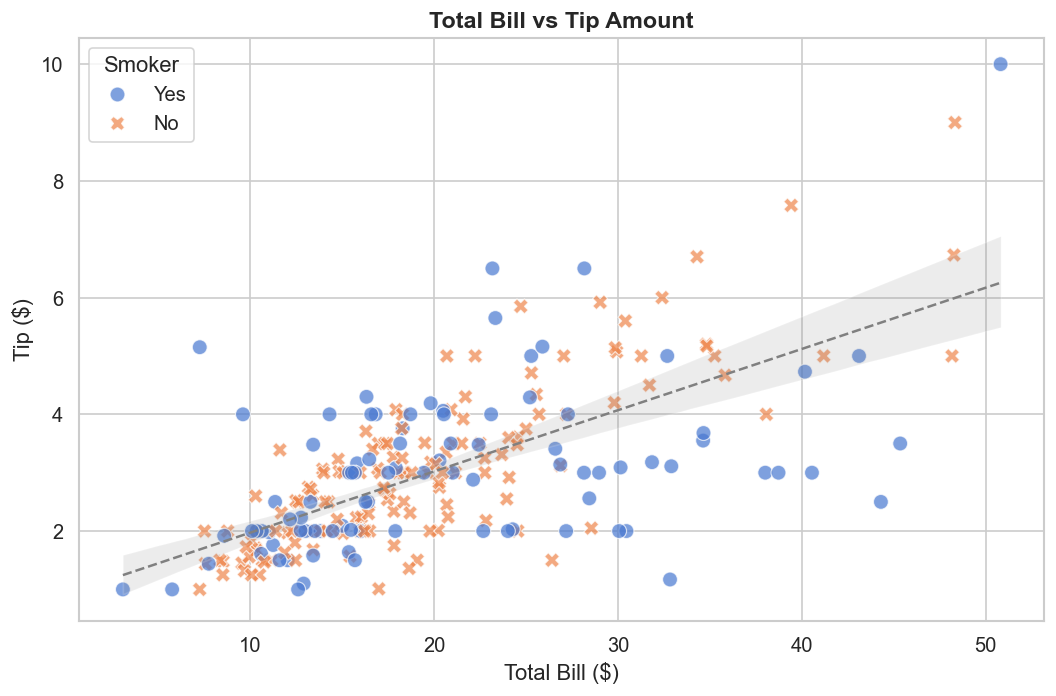

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df, x="total_bill", y="tip",
    hue="smoker", style="smoker",
    s=80, alpha=0.7, ax=ax
)

# Add a regression line for all data
sns.regplot(
    data=df, x="total_bill", y="tip",
    scatter=False, color="grey", line_kws={"lw": 1.5, "ls": "--"}, ax=ax
)

ax.set_title("Total Bill vs Tip Amount", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Tip ($)")
ax.legend(title="Smoker")
plt.tight_layout()
plt.show()

### Chart 2 — Tip Percentage by Day & Time

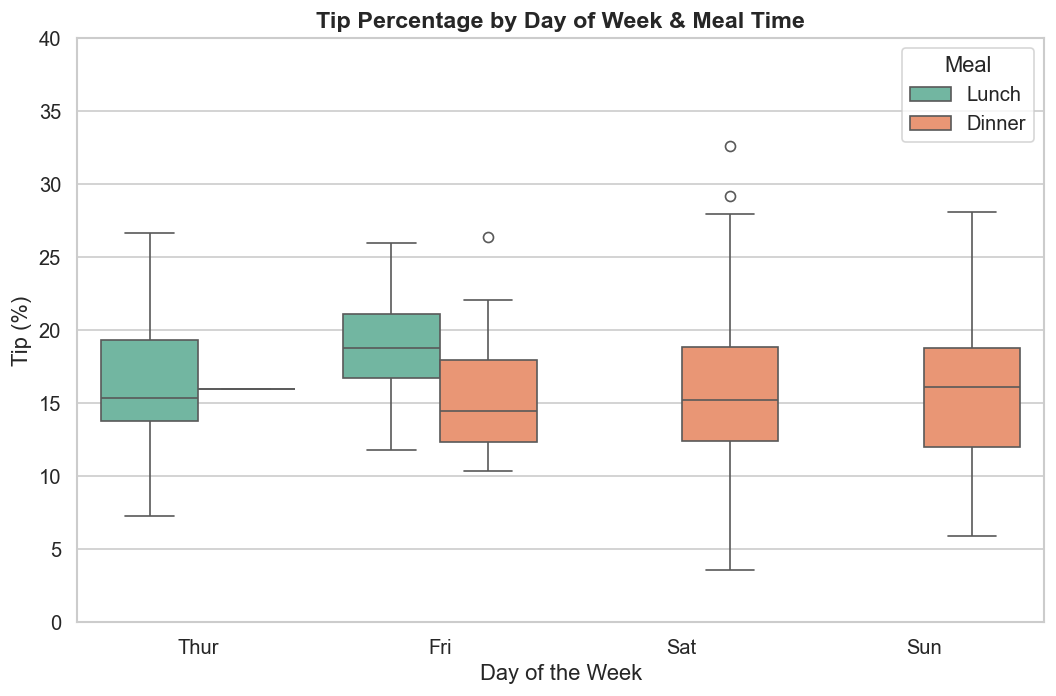

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=df, x="day", y="tip_pct",
    hue="time", palette="Set2",
    order=["Thur", "Fri", "Sat", "Sun"],
    ax=ax
)

ax.set_title("Tip Percentage by Day of Week & Meal Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of the Week")
ax.set_ylabel("Tip (%)")
ax.legend(title="Meal")
ax.set_ylim(0, 40)
plt.tight_layout()
plt.show()

### Chart 3 — Average Tip % by Party Size

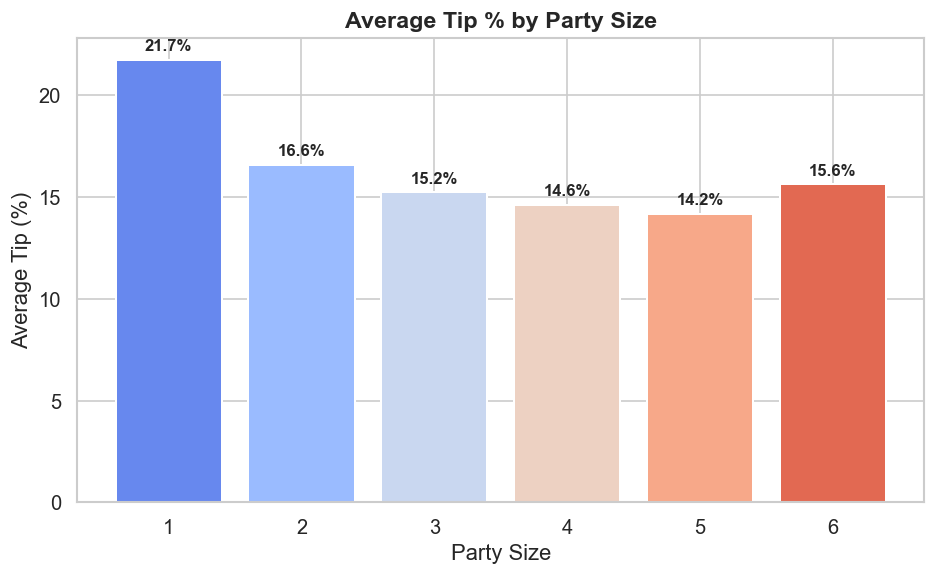

In [14]:
size_tip = df.groupby("size")["tip_pct"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    size_tip["size"], size_tip["tip_pct"],
    color=sns.color_palette("coolwarm", len(size_tip)),
    edgecolor="white", linewidth=1.2
)

# Annotate each bar
for bar, val in zip(bars, size_tip["tip_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Average Tip % by Party Size", fontsize=14, fontweight="bold")
ax.set_xlabel("Party Size")
ax.set_ylabel("Average Tip (%)")
ax.set_xticks(size_tip["size"])
plt.tight_layout()
plt.show()

### Chart 4 — Distribution of Tips: Smoker vs Non-Smoker

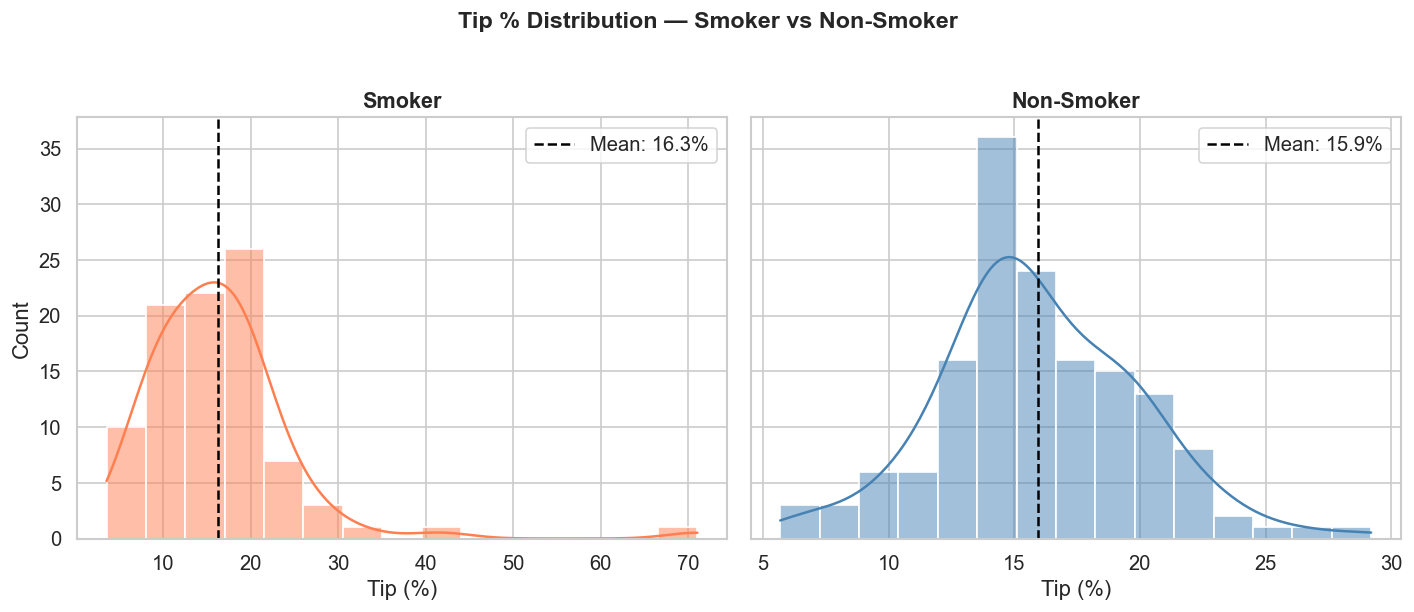

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (label, group) in zip(axes, df.groupby("smoker", observed=True)):
    sns.histplot(
        group["tip_pct"], bins=15, kde=True,
        color="coral" if label == "Yes" else "steelblue",
        edgecolor="white", ax=ax
    )
    ax.axvline(group["tip_pct"].mean(), color="black", ls="--", lw=1.5, label=f'Mean: {group["tip_pct"].mean():.1f}%')
    ax.set_title(f"{'Smoker' if label == 'Yes' else 'Non-Smoker'}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tip (%)")
    ax.legend()

fig.suptitle("Tip % Distribution — Smoker vs Non-Smoker", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Chart 5 — Correlation Heatmap

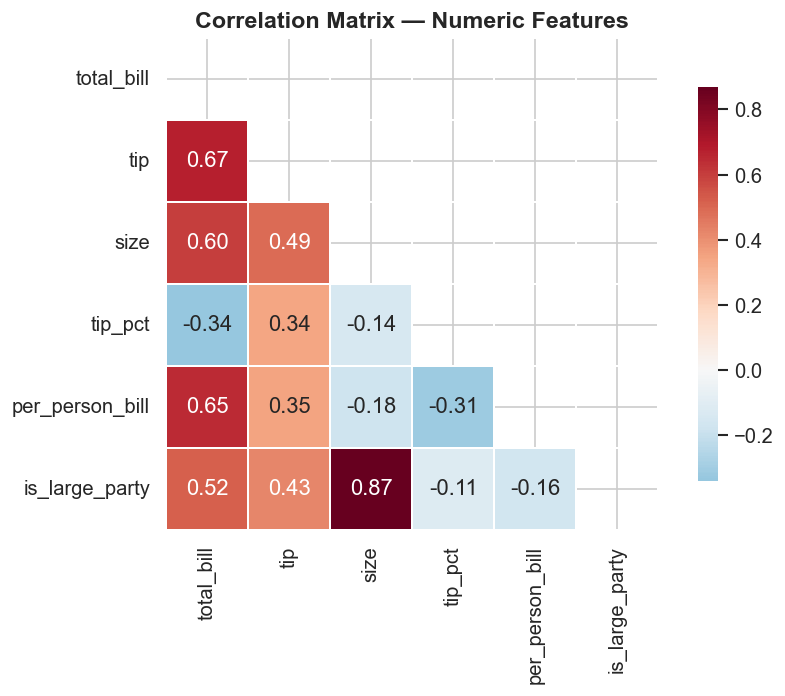

In [16]:
# Select numeric columns for the correlation matrix
numeric_cols = df.select_dtypes(include="number")
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    square=True, linewidths=1,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Conclusion

### Key Findings

- **Tips scale with bill size** — there's a strong positive correlation (r ≈ 0.68) between `total_bill` and `tip`, but the relationship is *sub-linear*: people tip a **lower percentage** on bigger bills.
- **Smokers ≠ bad tippers** — contrary to a common assumption, smokers tip a slightly *higher* percentage on average. Their tip distribution is more spread out (higher variance), suggesting more extreme highs and lows.
- **Large parties tip less %** — parties of 5–6 people tip around 14–15% on average vs. 18–19% for solo / couple diners. The absolute tip is higher, but the percentage drops notably.
- **Weekends drive volume, not generosity** — Saturday and Sunday account for ~70% of bills, but Thursday and Friday lunch-goers tip a higher percentage. Weekend dinners involve larger bills, which dilutes the tip %.
- **Gender gap is marginal** — male and female bill-payers tip nearly the same percentage overall; any visible difference is within noise for this sample size.

---

*Notebook complete. This analysis used **pandas**, **seaborn**, **matplotlib**, and **numpy**.  
Dataset source: `seaborn.load_dataset("tips")` — originally from Bryant & Smith (1995).*